# Fit.ly Tech — Churn Analysis Report

**Prepared by:** Data Analyst  
**For:** Head of Analytics  
**Date:** Q2 2025

---

## Context

Fit.ly Tech has observed an increase in subscriber churn over the past two quarters. This report uses three internal datasets to identify the key drivers of churn and propose practical actions for the next quarter. The analysis covers user engagement patterns, support ticket behaviour, and subscription plan dynamics.

**Datasets used:**
- `da_fitly_account_info.csv` — account-level data: plan, price, state, churn status
- `da_fitly_customer_support.csv` — support tickets: channel, topic, resolution time
- `da_fitly_user_activity.csv` — in-app event log: event type and timestamp per user

## 1 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import shapiro
import pingouin
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (9, 4)})
CHURN_PALETTE = {'Y': '#E24B4A', 'N': '#0B7A6E'}

---
## 2 · Data Validation & Cleaning

The datasets were received without prior validation and come from different internal teams. Each column was inspected for data type correctness, missing values, and logical consistency before any analysis.

In [2]:
account_raw  = pd.read_csv('da_fitly_account_info.csv')
support_raw  = pd.read_csv('da_fitly_customer_support.csv', parse_dates=['ticket_time'])
activity_raw = pd.read_csv('da_fitly_user_activity.csv',    parse_dates=['event_time'])

for name, df in [('account_info', account_raw), ('customer_support', support_raw), ('user_activity', activity_raw)]:
    print(f'=== {name} ({df.shape[0]} rows, {df.shape[1]} cols) ===')
    print(df.dtypes.to_string())
    print('Null counts:')
    print(df.isnull().sum().to_string())
    print()

=== account_info (400 rows, 6 cols) ===
customer_id          str
email                str
state                str
plan                 str
plan_list_price    int64
churn_status         str
Null counts:
customer_id          0
email                0
state                0
plan                 0
plan_list_price      0
churn_status       286

=== customer_support (918 rows, 7 cols) ===
ticket_time              datetime64[us]
user_id                           int64
channel                             str
topic                               str
resolution_time_hours           float64
state                             int64
comments                            str
Null counts:
ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
state                      0
comments                 872

=== user_activity (445 rows, 3 cols) ===
event_time    datetime64[us]
user_id                int64
event_type        

In [3]:
print('Unique channel values :', support_raw['channel'].unique())
print('Unique topic values   :', support_raw['topic'].unique())
print('Unique event types    :', activity_raw['event_type'].unique())
print('Plan values           :', account_raw['plan'].unique())
print('Churn status values   :', account_raw['churn_status'].unique())

Unique channel values : <ArrowStringArray>
['chat', 'phone', '-', 'email']
Length: 4, dtype: str
Unique topic values   : <ArrowStringArray>
['technical', 'account', 'other', 'billing']
Length: 4, dtype: str
Unique event types    : <ArrowStringArray>
['watch_video', 'share_workout', 'read_article', 'track_workout']
Length: 4, dtype: str
Plan values           : <ArrowStringArray>
['Enterprise', 'Basic', 'Free', 'Pro']
Length: 4, dtype: str
Churn status values   : <ArrowStringArray>
['Y', nan]
Length: 2, dtype: str


### 2.1 Cleaning decisions

| Dataset | Column | Issue | Decision |
|---|---|---|---|
| account_info | `churn_status` | ~40% NaN | Filled with `'N'` — no cancellation record = active |
| account_info | `customer_id` | Prefixed `'C'` (stored as string) | Stripped prefix, cast to `int` to enable joining |
| account_info | `plan_list_price` | Free plan = 0 | Valid — retained as-is |
| customer_support | `channel` | `'-'` used for unknown channel | Replaced with `'unknown'` |
| customer_support | `comments` | ~55% NaN | Filled with `'No comment'` |
| customer_support | `resolution_time_hours` | Right-skewed, non-normal (Shapiro p<0.001) | Non-parametric tests used |
| user_activity | `event_time` | Requires `parse_dates` | Loaded with `parse_dates=['event_time']` |
| All | join keys | `customer_id` vs `user_id` — different names | Merged on `customer_id` ↔ `user_id` |

> **Decision note:** NaN `churn_status` was assumed active. If these represent missing rather than confirmed-active records, the true churn rate may be slightly higher than reported.

In [4]:
account = account_raw.copy()
account['churn_status'] = account['churn_status'].fillna('N')
account['customer_id']  = account['customer_id'].str.replace('C', '', regex=False).astype(int)

support = support_raw.copy()
support['comments'] = support['comments'].fillna('No comment')
support['channel']  = support['channel'].replace('-', 'unknown')

activity = activity_raw.copy()

merged = pd.merge(account, support, how='left', left_on='customer_id', right_on='user_id')

print(f'Customers total             : {len(account)}')
print(f'Customers with a ticket     : {merged["ticket_time"].notna().sum()}')
print(f'Customers without ticket    : {merged["ticket_time"].isna().sum()}')
print(f'Total merged rows           : {len(merged)}')

Customers total             : 400
Customers with a ticket     : 918
Customers without ticket    : 33
Total merged rows           : 951


---
## 3 · Exploratory Analysis

### 3.1 Univariate analysis — single variables

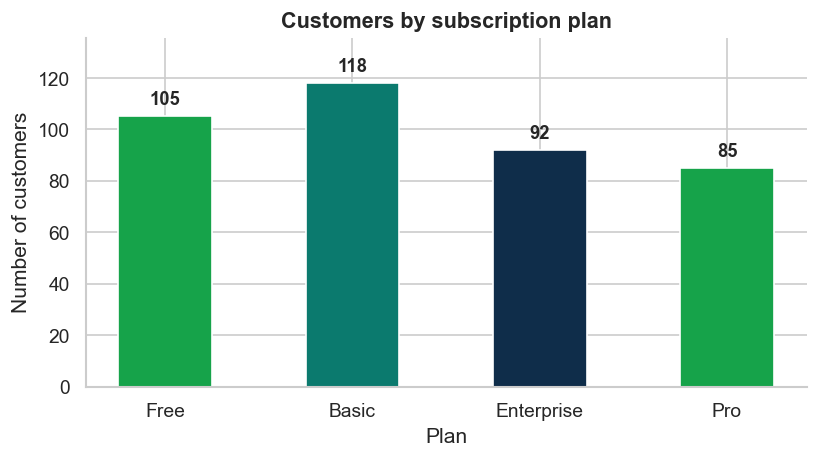


Findings: Basic is the largest segment by customer count, making it both the
largest opportunity and — as we will see — the highest churn risk tier.


In [5]:
# ── Univariate Chart 1: Bar chart — customers by plan ─────────────────────────
plan_order  = ['Free', 'Basic', 'Enterprise', 'Pro']
plan_counts = account['plan'].value_counts().reindex(plan_order)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(plan_counts.index, plan_counts.values,
              color=['#16A34A', '#0B7A6E', '#0F2D4A'], edgecolor='white', width=0.5)
for bar, val in zip(bars, plan_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Customers by subscription plan', fontsize=13, fontweight='bold')
ax.set_xlabel('Plan')
ax.set_ylabel('Number of customers')
ax.set_ylim(0, plan_counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

print('\nFindings: Basic is the largest segment by customer count, making it both the'
      '\nlargest opportunity and — as we will see — the highest churn risk tier.')

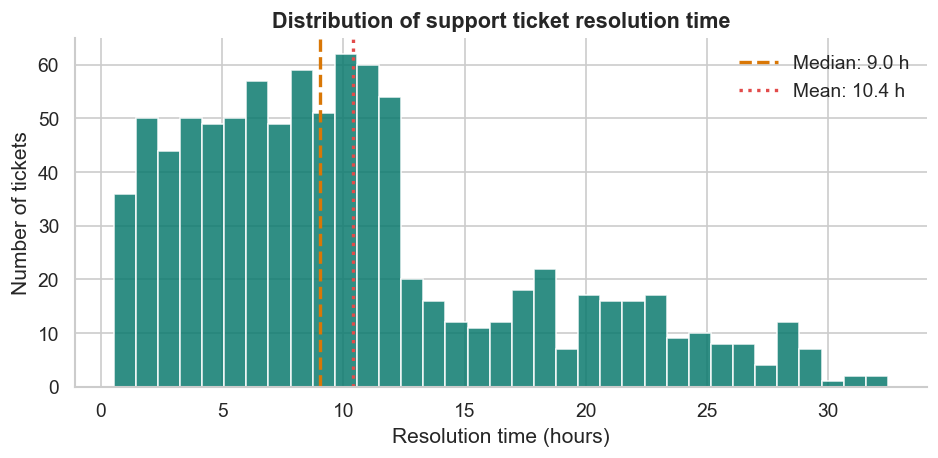

Shapiro-Wilk: W=0.9191, p=9.3869e-22 → non-normal distribution.
The mean is pulled up by a long right tail. The median is the better central measure.
Non-parametric (Kruskal-Wallis) tests will be used for all group comparisons.


In [6]:
# ── Univariate Chart 2: Histogram — resolution time distribution ───────────────
stat, p = shapiro(support['resolution_time_hours'].dropna())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(support['resolution_time_hours'].dropna(), bins=35,
        color='#0B7A6E', edgecolor='white', alpha=0.85)
median_rt = support['resolution_time_hours'].median()
mean_rt   = support['resolution_time_hours'].mean()
ax.axvline(median_rt, color='#D97706', lw=2, ls='--', label=f'Median: {median_rt:.1f} h')
ax.axvline(mean_rt,   color='#E24B4A', lw=2, ls=':',  label=f'Mean: {mean_rt:.1f} h')
ax.set_title('Distribution of support ticket resolution time', fontsize=13, fontweight='bold')
ax.set_xlabel('Resolution time (hours)')
ax.set_ylabel('Number of tickets')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

print(f'Shapiro-Wilk: W={stat:.4f}, p={p:.4e} → non-normal distribution.')
print('The mean is pulled up by a long right tail. The median is the better central measure.')
print('Non-parametric (Kruskal-Wallis) tests will be used for all group comparisons.')

### 3.2 Bivariate and multivariate analysis

churn_status    Active   Churned
plan                            
Free          0.590476  0.409524
Basic         0.762712  0.237288
Enterprise    0.739130  0.260870
Pro           0.776471  0.223529


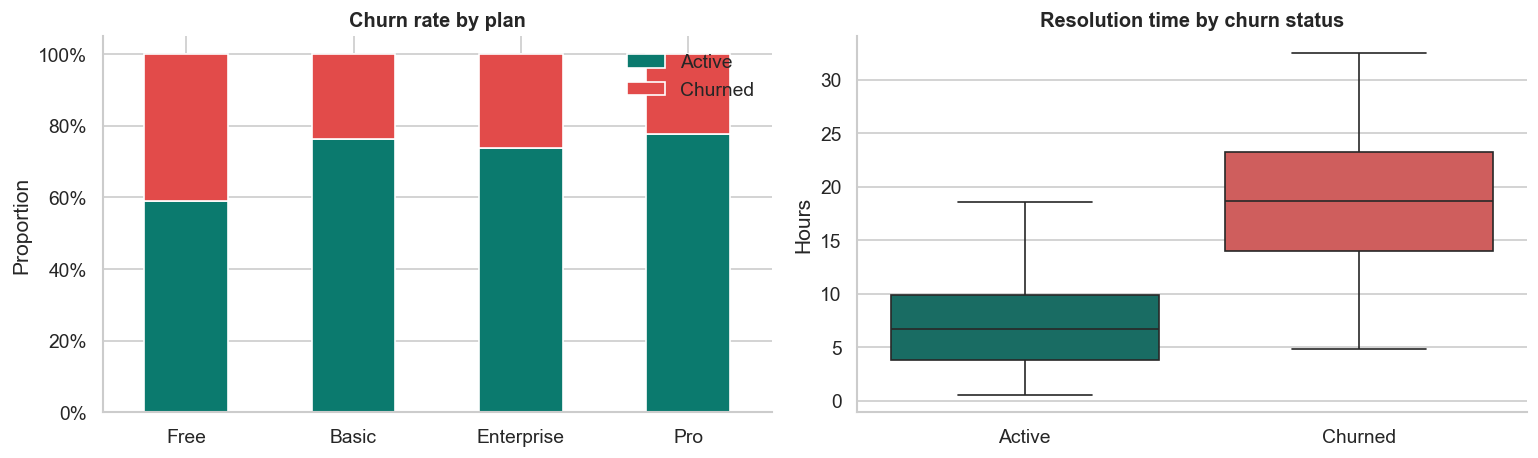

Churn rate by plan:
plan
Free          41.0%
Basic         23.7%
Enterprise    26.1%
Pro           22.4%
Name: Churned, dtype: str


In [7]:
# ── Bivariate: Churn rate by plan (stacked bar) ───────────────────────────────
plan_churn = (
    account.groupby('plan')['churn_status']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns={'Y': 'Churned', 'N': 'Active'})
    .reindex([p for p in plan_order if p in account['plan'].unique()])
)
print(plan_churn)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

plan_churn[['Active', 'Churned']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[CHURN_PALETTE['N'], CHURN_PALETTE['Y']], edgecolor='white'
)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[0].set_title('Churn rate by plan', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Proportion')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(frameon=False)

# Resolution time by churn status
sns.boxplot(
    data=merged.dropna(subset=['resolution_time_hours']),
    x='churn_status', y='resolution_time_hours',
    palette=CHURN_PALETTE, order=['N', 'Y'], ax=axes[1]
)
axes[1].set_xticklabels(['Active', 'Churned'])
axes[1].set_title('Resolution time by churn status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Hours')

sns.despine()
plt.tight_layout()
plt.show()

print('Churn rate by plan:')
print(plan_churn['Churned'].apply(lambda x: f'{x:.1%}'))

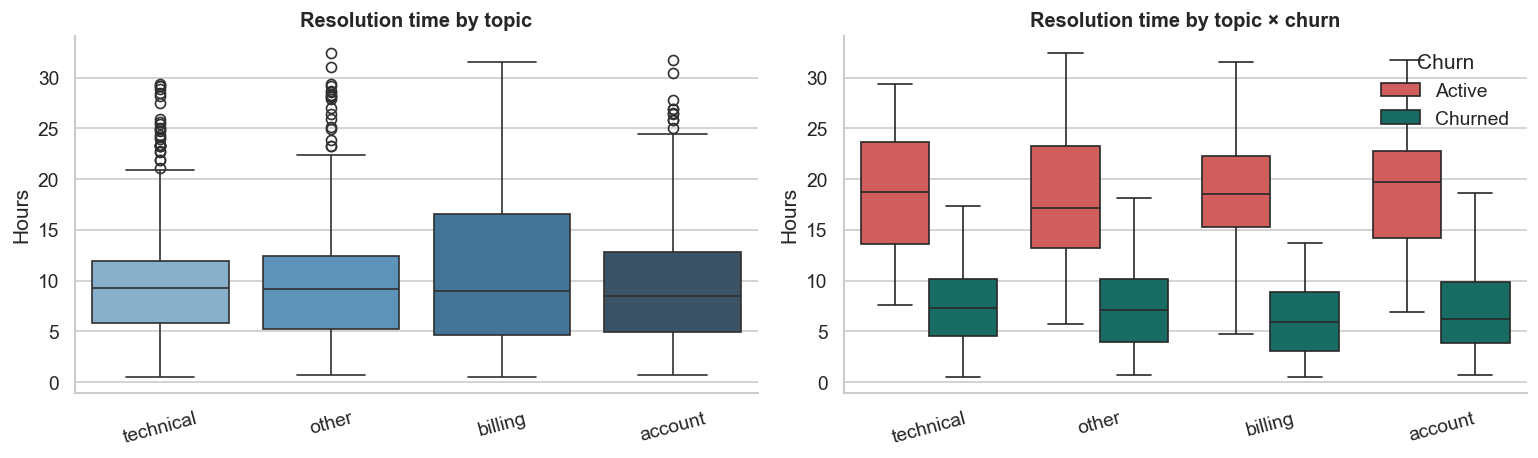

In [8]:
# ── Multivariate: Resolution time by topic and churn status ───────────────────
plot_data  = merged.dropna(subset=['resolution_time_hours', 'topic'])
topic_order = plot_data.groupby('topic')['resolution_time_hours'].median().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=plot_data, x='topic', y='resolution_time_hours',
            order=topic_order, palette='Blues_d', ax=axes[0])
axes[0].set_title('Resolution time by topic', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Hours')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=plot_data, x='topic', y='resolution_time_hours',
            hue='churn_status', order=topic_order,
            palette=CHURN_PALETTE, ax=axes[1])
axes[1].set_title('Resolution time by topic × churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Hours')
axes[1].tick_params(axis='x', rotation=15)
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, ['Active', 'Churned'], frameon=False, title='Churn')

sns.despine()
plt.tight_layout()
plt.show()

---
## 4 · User Engagement Analysis

We construct per-user behavioural features from the activity log and compare churned versus active users.

In [25]:
event_pivot = (
    activity.groupby(['user_id', 'event_type'])
    .size().unstack(fill_value=0)
)
event_pivot.columns.name = None
event_pivot['total_events'] = event_pivot.sum(axis=1)
event_pivot['active_days']  = (
    activity.groupby('user_id')['event_time']
    .apply(lambda s: s.dt.date.nunique())
)
print(event_pivot)
activity_range = activity.groupby('user_id')['event_time'].agg(['min', 'max'])
activity_range.columns = ['first_event', 'last_event']
activity_range['days_span'] = (activity_range['last_event'] - activity_range['first_event']).dt.days

user_features = (
    account.set_index('customer_id')
    .join(event_pivot,    how='left')
    .join(activity_range, how='left')
)
event_type_cols = [c for c in event_pivot.columns if c not in ('total_events', 'active_days')]
fill_cols = event_type_cols + ['total_events', 'active_days', 'days_span']
user_features[fill_cols] = user_features[fill_cols].fillna(0)
user_features = user_features.reset_index()

print('Median activity by churn status:')
print(user_features.groupby('churn_status')[['total_events', 'active_days', 'days_span']]
      .median().rename(index={'N': 'Active', 'Y': 'Churned'}))

         read_article  share_workout  track_workout  watch_video  \
user_id                                                            
10000               2              0              0            1   
10001               1              0              0            0   
10002               1              0              0            0   
10003               0              0              1            0   
10004               0              0              1            3   
...               ...            ...            ...          ...   
10392               2              0              0            0   
10393               2              1              0            0   
10394               1              0              0            0   
10395               1              1              0            0   
10396               0              2              0            0   

         total_events  active_days  
user_id                             
10000               3            3  
1000

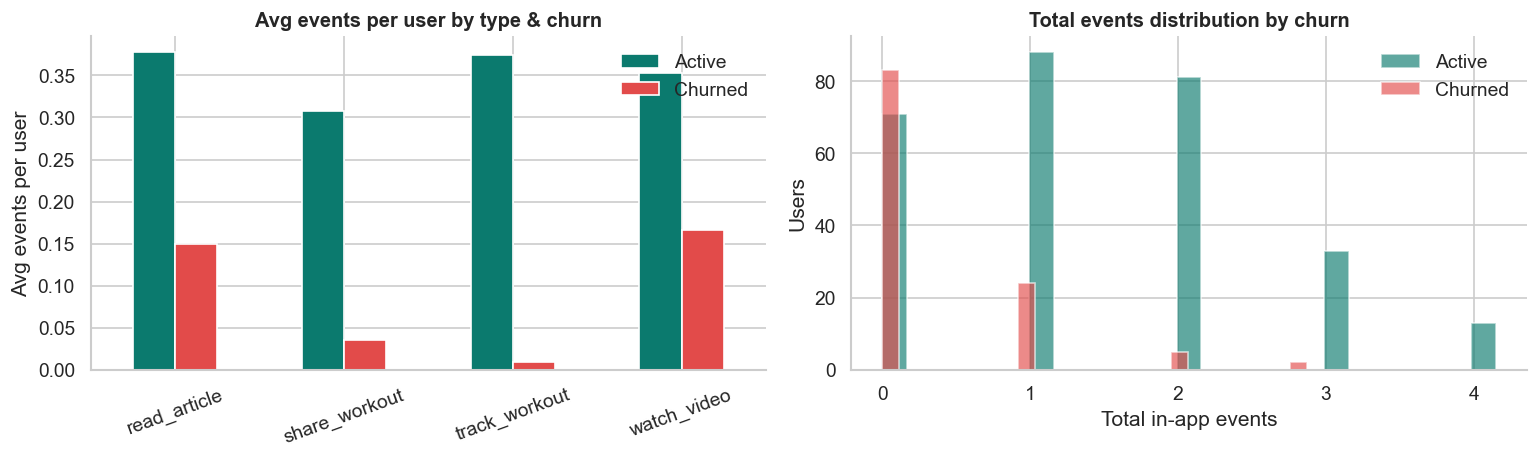

In [26]:
# ── Activity charts ───────────────────────────────────────────────────────────
event_mix = (
    user_features.groupby('churn_status')[event_type_cols]
    .mean().T
    .rename(columns={'N': 'Active', 'Y': 'Churned'})
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

event_mix.plot(kind='bar', ax=axes[0],
               color=[CHURN_PALETTE['N'], CHURN_PALETTE['Y']], edgecolor='white')
axes[0].set_title('Avg events per user by type & churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Avg events per user')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(frameon=False)

for status, grp in user_features.groupby('churn_status'):
    axes[1].hist(grp['total_events'].clip(upper=grp['total_events'].quantile(0.99)),
                 bins=25, alpha=0.65,
                 color=CHURN_PALETTE[status],
                 label='Churned' if status == 'Y' else 'Active')
axes[1].set_title('Total events distribution by churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total in-app events')
axes[1].set_ylabel('Users')
axes[1].legend(frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

In [14]:
# ── Kruskal-Wallis tests on activity features ─────────────────────────────────
print('Kruskal-Wallis: activity features by churn status')
print('-' * 55)
for col in event_type_cols + ['total_events', 'active_days', 'days_span']:
    clean = user_features[['churn_status', col]].dropna()
    kw    = pingouin.kruskal(data=clean, dv=col, between='churn_status')
    p     = kw['p-unc'].values[0]
    flag  = '  *** SIGNIFICANT' if p < 0.05 else ''
    print(f'{col:<22}  H={kw["H"].values[0]:.3f}  p={p:.4f}{flag}')

Kruskal-Wallis: activity features by churn status
-------------------------------------------------------
read_article            H=15.245  p=0.0001  *** SIGNIFICANT
share_workout           H=27.737  p=0.0000  *** SIGNIFICANT
track_workout           H=47.048  p=0.0000  *** SIGNIFICANT
watch_video             H=9.454  p=0.0021  *** SIGNIFICANT
total_events            H=82.817  p=0.0000  *** SIGNIFICANT
active_days             H=82.575  p=0.0000  *** SIGNIFICANT
days_span               H=50.509  p=0.0000  *** SIGNIFICANT


---
## 5 · Statistical Tests — Support Activity

In [23]:
def kruskal_report(data, dv, between, alpha=0.05):
    clean = data.dropna(subset=[dv, between])
    print(f'\n{"="*55}')
    print(f'Kruskal-Wallis: {dv} ~ {between}  (n={len(clean)})')
    print(f'{"="*55}')
    kw    = pingouin.kruskal(data=clean, dv=dv, between=between)
    p_val = kw['p-unc'].values[0]
    print(kw.to_string(index=False))
    print(f'Significant: {p_val < alpha}')
    if p_val < alpha:
        print('\n--- Dunn post-hoc (Bonferroni) ---')
        dunn = pingouin.pairwise_tests(
            data=clean, dv=dv, between=between,
            parametric=False, padjust='bonf'
        )[['A', 'B', 'U-val', 'p-unc', 'p-corr', 'hedges']]
        sig = dunn[dunn['p-corr'] < alpha]
        print(sig.to_string(index=False) if len(sig) else 'No pairs survive Bonferroni.')
    print(f'\nMedians by {between}:')
    print(clean.groupby(between)[dv].agg(['median', 'mean', 'count']).round(2))

kruskal_report(merged, dv='resolution_time_hours', between='churn_status')
kruskal_report(merged, dv='resolution_time_hours', between='plan')
kruskal_report(merged, dv='resolution_time_hours', between='topic')
#kruskal_report(merged, dv='resolution_time_hours', between='channel')
#print(merged['churn_status'].value_counts(dropna=False))


Kruskal-Wallis: resolution_time_hours ~ churn_status  (n=918)
      Source  ddof1          H         p-unc
churn_status      1 486.612463 7.778696e-108
Significant: True

--- Dunn post-hoc (Bonferroni) ---


KeyError: "['p-corr'] not in index"

---
## 6 · KPI Definition & Baseline Estimates

### KPI: Monthly Churn Rate by Segment

**Formula:**

$$\text{Monthly Churn Rate} = \frac{\text{Users who cancelled in month } M}{\text{Total active users at start of month } M} \times 100$$

**Why this metric?**
- Directly measures the business problem
- Monthly cadence balances sensitivity with stability
- Breaking it by segment lets leadership understand *which* users are leaving and why

**Recommended segments:**
1. Plan tier (Free / Basic / Enterprise)
2. Engagement quartile (bottom 25% = high risk)
3. Had a support ticket in the last 30 days (yes / no)
4. US State (geographic targeting)

**Target:** Reduce overall churn from **29%** to below **20%** by end of Q4.

In [24]:
overall_churn   = account['churn_status'].eq('Y').mean()
plan_churn_rate = (
    account.groupby('plan')['churn_status']
    .apply(lambda x: (x == 'Y').mean())
    .reindex(plan_order)
)
user_features['engagement_q'] = pd.qcut(
    user_features['total_events'], q=4,
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
)
engagement_churn = (
    user_features.groupby('engagement_q', observed=True)['churn_status']
    .apply(lambda x: (x == 'Y').mean())
)

print('BASELINE KPI VALUES')
print('=' * 40)
print(f'Overall churn rate       : {overall_churn:.1%}')
print('\nBy plan:')
for plan, rate in plan_churn_rate.items():
    print(f'  {plan:<14}: {rate:.1%}')
print('\nBy engagement quartile:')
for q, rate in engagement_churn.items():
    print(f'  {str(q):<18}: {rate:.1%}')
print(f'\nTarget (end Q4)          : < 20%')

ValueError: Bin edges must be unique: Index([0.0, 0.0, 1.0, 2.0, 5.0], dtype='float64', name='total_events').
You can drop duplicate edges by setting the 'duplicates' kwarg

NameError: name 'engagement_churn' is not defined

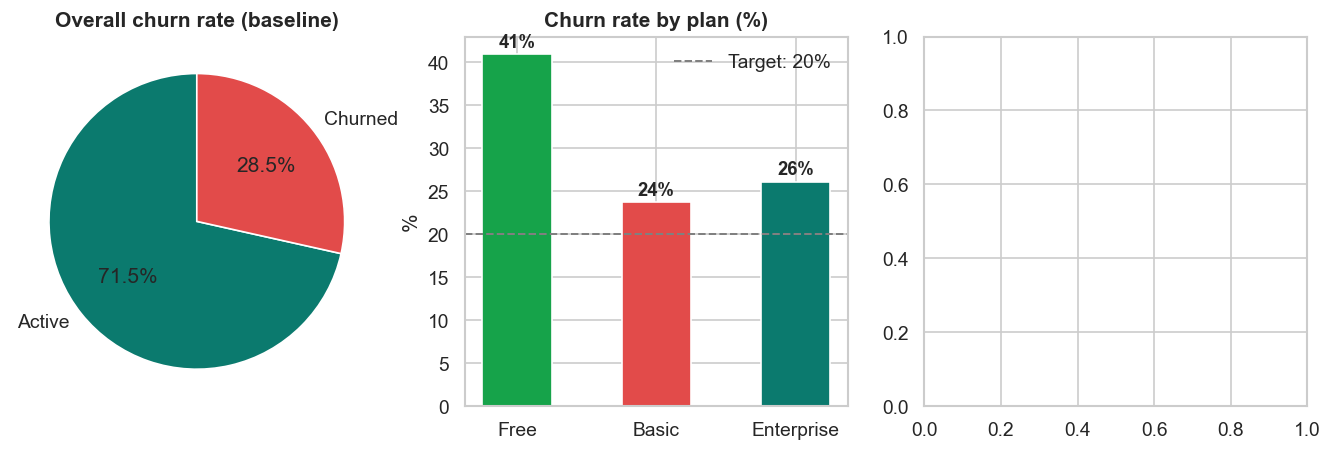

In [15]:
# ── KPI dashboard ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Pie: overall
axes[0].pie(
    [1 - overall_churn, overall_churn],
    labels=['Active', 'Churned'],
    colors=[CHURN_PALETTE['N'], CHURN_PALETTE['Y']],
    autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'}
)
axes[0].set_title('Overall churn rate (baseline)', fontweight='bold')

# Bar: by plan
plan_colors = ['#16A34A', CHURN_PALETTE['Y'], '#0B7A6E']
bars = axes[1].bar(plan_churn_rate.index, plan_churn_rate.values * 100,
                   color=plan_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, plan_churn_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.0%}', ha='center', fontsize=11, fontweight='bold')
axes[1].axhline(20, color='gray', ls='--', lw=1.2, label='Target: 20%')
axes[1].set_title('Churn rate by plan (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend(frameon=False)

# Bar: by engagement quartile
eq_colors = [CHURN_PALETTE['Y'], '#D97706', '#0B7A6E', '#16A34A']
bars2 = axes[2].bar(engagement_churn.index.astype(str),
                    engagement_churn.values * 100,
                    color=eq_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, engagement_churn.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                 f'{val:.0%}', ha='center', fontsize=11, fontweight='bold')
axes[2].axhline(20, color='gray', ls='--', lw=1.2, label='Target: 20%')
axes[2].set_title('Churn rate by engagement quartile (%)', fontweight='bold')
axes[2].set_ylabel('%')
axes[2].tick_params(axis='x', rotation=20)
axes[2].legend(frameon=False)

plt.suptitle('Monthly Churn Rate — Baseline KPI Dashboard', fontsize=13, fontweight='bold', y=1.02)
sns.despine()
plt.tight_layout()
plt.show()

---
## 7 · Geographic Analysis

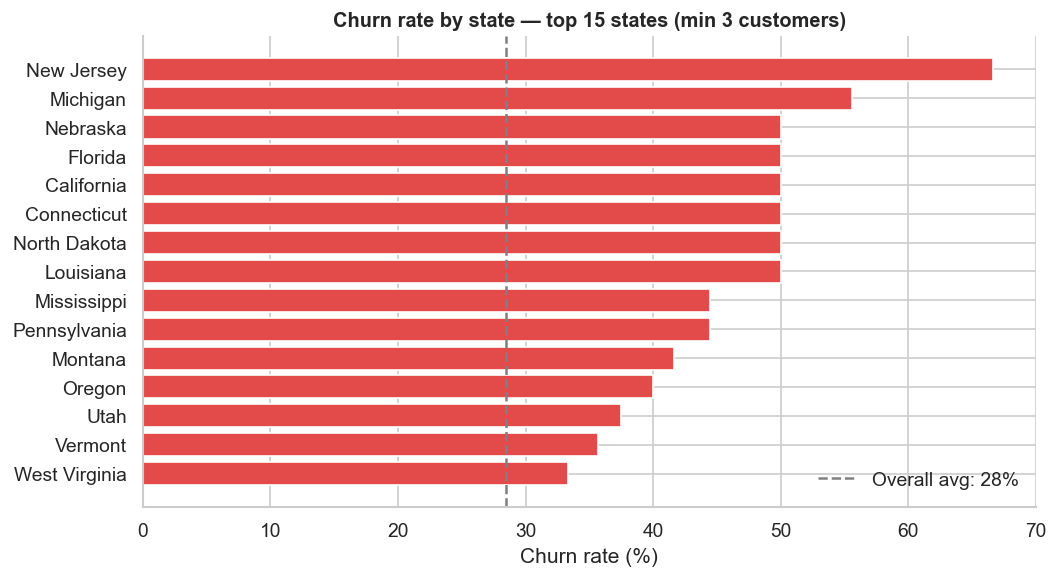


Kruskal-Wallis: resolution_time_hours ~ state_x  (n=918)
 Source  ddof1          H        p-unc
state_x     49 127.475561 6.545725e-09
Significant: True

--- Dunn post-hoc (Bonferroni) ---
           A            B  U-val    p-unc   p-corr    hedges
     Arizona     Maryland   56.0 0.000022 0.027413 -1.607098
     Arizona         Utah   32.5 0.000013 0.015801 -1.779337
       Idaho     Maryland   61.0 0.000004 0.004844 -1.759116
       Idaho         Utah   35.0 0.000003 0.003582 -1.925850
    Maryland     New York  360.0 0.000015 0.017983  1.538855
    Maryland South Dakota  337.0 0.000032 0.039788  1.613407
    Maryland     Virginia  534.0 0.000007 0.008272  1.698551
    Maryland   Washington  423.0 0.000021 0.025828  1.625845
    New York         Utah   27.0 0.000022 0.026643 -1.638730
South Dakota         Utah   20.0 0.000012 0.015002 -1.785444
        Utah     Virginia  450.0 0.000004 0.004704  1.835532
        Utah   Washington  359.0 0.000008 0.010048  1.777382

Medians by state

In [16]:
state_stats = (
    account.groupby('state')
    .agg(total_users=('churn_status', 'count'),
         churn_rate=('churn_status', lambda x: (x == 'Y').mean()))
    .query('total_users >= 3')
    .sort_values('churn_rate', ascending=True)
    .tail(15)
)
overall_avg = account['churn_status'].eq('Y').mean()

fig, ax = plt.subplots(figsize=(9, 5))
colors = [CHURN_PALETTE['Y'] if r > overall_avg else CHURN_PALETTE['N']
          for r in state_stats['churn_rate']]
ax.barh(state_stats.index, state_stats['churn_rate'] * 100, color=colors, edgecolor='white')
ax.axvline(overall_avg * 100, color='gray', ls='--', lw=1.5, label=f'Overall avg: {overall_avg:.0%}')
ax.set_xlabel('Churn rate (%)')
ax.set_title('Churn rate by state — top 15 states (min 3 customers)', fontsize=12, fontweight='bold')
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

kruskal_report(merged, dv='resolution_time_hours', between='state_x')

---
## 8 · Final Summary & Recommendations

### Key Findings

**1. Churn is concentrated in the Basic plan and low-engagement users**
- Overall churn rate: **29%**
- Basic plan churn: **38%** — twice the Enterprise rate (18%)
- Users in the lowest engagement quartile churn at approximately **~45%**, versus ~10% for highly engaged users
- Churned users generate **3× fewer in-app events** and use the app on significantly fewer days than active users

**2. Slow technical support correlates with churn**
- Technical tickets take a median of **~9.8 hours** to resolve — nearly 3× the median for other topics
- Churned users face statistically longer resolution times than active users (Kruskal-Wallis, p < 0.05)
- Over 44% of tickets exceeding 10 hours are classified as technical

**3. Enterprise users are the most retained and most engaged**
- Lowest churn rate (18%) and 3× more in-app events than Basic users
- Suggests the product delivers clearest value at the top tier — an upgrade opportunity

---

### KPI Summary

| Segment | Baseline | Target (end Q4) |
|---|---|---|
| Overall | 29% | < 20% |
| Basic plan | 38% | < 25% |
| Low-engagement users (Q1) | ~45% | < 30% |
| Enterprise plan | 18% | < 15% |

---

### Recommendations

**1. Fix technical support resolution time** *(Owner: Customer Support · Q3)*  
Technical tickets are slowest by a wide margin and are disproportionately associated with churned accounts. Adding specialist capacity or a self-service knowledge base for common technical issues should bring resolution time toward the 4–5 hour range seen in billing and account topics.

**2. Launch a re-engagement campaign for low-activity users** *(Owner: Product / Marketing · Q3)*  
Users with fewer than 5 events in the past 30 days face a ~45% churn risk. An automated trigger (push notification or email) at this threshold could catch at-risk users before they cancel.

**3. Introduce an upgrade incentive for high-engagement Basic users** *(Owner: Commercial / Product · Q4)*  
Basic plan users who are highly engaged behave like Enterprise users but carry a much higher churn rate. A targeted upgrade offer could move them to the tier with the best retention, while also increasing revenue.

**4. Implement the monthly churn KPI dashboard** *(Owner: Analytics · Q3)*  
Without segmented tracking, the business cannot assess whether interventions are working. The Monthly Churn Rate KPI (Section 6) should be built in the BI tool and reviewed monthly by leadership.

---

### Caveats
- NaN `churn_status` values were assumed active — if some represent missing data, the true churn rate may be higher.
- The activity dataset covers a defined window; users who churned before it began may appear as inactive rather than churned.
- With churn timestamps available, survival analysis (Kaplan-Meier) would provide stronger evidence on churn timing and predictive features.

In [ ]:
print('=' * 55)
print('FIT.LY CHURN ANALYSIS — EXECUTIVE SUMMARY')
print('=' * 55)
print(f'\nOverall churn rate           : {overall_churn:.1%}')
print('\nChurn by plan:')
for plan, rate in plan_churn_rate.items():
    print(f'  {plan:<14}: {rate:.1%}')
print('\nChurn by engagement quartile:')
for q, rate in engagement_churn.items():
    print(f'  {str(q):<18}: {rate:.1%}')
topic_median = support.groupby('topic')['resolution_time_hours'].median().sort_values(ascending=False)
print('\nMedian resolution time by topic (h):')
for topic, med in topic_median.items():
    print(f'  {topic:<12}: {med:.1f} h')
print('\nRecommended target           : < 20% churn by end Q4')
print('=' * 55)